In [24]:
!nvidia-smi

Fri May 10 16:31:07 2024       
+-----------------------------------------------------------------------------+
| NVIDIA-SMI 470.103.01   Driver Version: 470.103.01   CUDA Version: 11.4     |
|-------------------------------+----------------------+----------------------+
| GPU  Name        Persistence-M| Bus-Id        Disp.A | Volatile Uncorr. ECC |
| Fan  Temp  Perf  Pwr:Usage/Cap|         Memory-Usage | GPU-Util  Compute M. |
|                               |                      |               MIG M. |
|===============================+======================+======================|
|   0  Tesla K80           Off  | 00000000:05:00.0 Off |                    0 |
| N/A   41C    P8    58W / 149W |     53MiB / 11441MiB |      0%      Default |
|                               |                      |                  N/A |
+-------------------------------+----------------------+----------------------+
|   1  Tesla K80           Off  | 00000000:06:00.0 Off |                    0 |
| N/A   

In [1]:
import os
import nibabel as nib
import numpy as np 
from collections import OrderedDict
import json
from pathlib import Path

from utils.helper import convert_nrrd_to_nifti, create_folder, plot_all_slices, plot_histogram, generate_binary_image, adjust_affine_for_spacing_and_origin, save_binary_image_with_adjusted_origin, make_if_dont_exist,load_nifti_file,convert_file_format,file_exists, load_nifti_file_af_datatype
from utils.metrics import dice_score_per_class, hausdorff_distance_per_class, ravd_per_class

In [2]:

# define dataset path
BASE_PATH = Path('./').resolve()
DATA_PATH = BASE_PATH / 'dataset'

project_name = 'HCFC1' #change here for different task name
task_name = 'Dataset002_' + project_name 

TRAINING_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'imagesTr'
GT_TRAINING_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'labelsTr'
TEST_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'imagesTs'
GT_TEST_DATASET_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name / 'labelsTs'
PREDICTION_RESULTS_PATH  = BASE_PATH / 'dataset/nnUNet_Prediction_Results' / task_name
TASK_PATH = BASE_PATH / 'dataset/nnUNet_raw_data' / task_name 

# setup environment variables
nnUNet_raw = BASE_PATH / 'dataset/nnUNet_raw_data'
nnUNet_preprocessed = BASE_PATH / 'dataset/nnUNet_preprocessed'
nnUNet_results = BASE_PATH / 'dataset/nnUNet_results'

In [3]:
%env nnUNet_raw=$nnUNet_raw
%env nnUNet_preprocessed=$nnUNet_preprocessed
%env nnUNet_results=$nnUNet_results

env: nnUNet_raw=/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_raw_data
env: nnUNet_preprocessed=/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_preprocessed
env: nnUNet_results=/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/dataset/nnUNet_results


In [4]:
import os
import nrrd
import os

def remove_nrrd_files(directory):
    """
    Removes all .nrrd files from the specified directory.

    Parameters:
    - directory: str, the path to the directory from which .nrrd files are to be deleted.
    """
    # Count of removed files
    removed_files = 0

    # List all files in the directory
    for file in os.listdir(directory):
        if file.endswith('.nrrd'):
            # Construct full file path
            file_path = os.path.join(directory, file)
            # Remove the file
            os.remove(file_path)
            removed_files += 1
            print(f"Removed: {file_path}")

    if removed_files == 0:
        print("No .nrrd files found to remove.")
    else:
        print(f"Total .nrrd files removed: {removed_files}")

def multiply_vol_save_nifti(source_path, binary_path, save_path):
    file_list = os.listdir(binary_path)
    for file in file_list:
        if file.endswith('.nii.gz'):
            binary_file = os.path.join(binary_path, file)
            
            new_file = file.replace(".nii.gz", "_0000.nii.gz")
            save_file = file.replace("_0000.nii.gz", ".nii.gz")
            
            source_file = os.path.join(source_path, new_file)
            print(source_file)
            save_vol = os.path.join(save_path, save_file)
            
            if file_exists(source_file) and file_exists(binary_file):
                source_data, s_shape, s_affine, s_datatype = load_nifti_file_af_datatype(source_file)
                binary_data, b_shape, b_affine, b_datatype = load_nifti_file_af_datatype(binary_file)
                
                new_data = source_data * binary_data

                # Convert the result to the appropriate data type
                new_data = new_data.astype(s_datatype)
                
                # Create a new NIfTI image
                new_img = nib.Nifti1Image(new_data, s_affine)

                # Save the new NIfTI image
                nib.save(new_img, save_vol)

                print('Saved successfully:', save_vol)
            else:
                print('File not exists:', source_file if not file_exists(source_file) else binary_file)



def multiply_vol_save_nrrd(source_path,binary_path, save_path):
    file_list = os.listdir(source_path)
    for file in file_list:
        if file.endswith('.nii.gz'):
            source_file = os.path.join(source_path,file)
            
            new_file = file.replace("_0000.nii.gz", ".nii.gz")
            save_file = file.replace("_0000.nii.gz", ".nrrd")
            
            binary_file = os.path.join(binary_path,new_file)
            save_vol = os.path.join(save_path,save_file)
            
            if (file_exists(source_file) and file_exists(binary_file)):
                source_data,s_shape, s_affine,s_datatype= load_nifti_file(source_file)
                binary_data,b_shape,b_affine,b_datatype = load_nifti_file(binary_file)
                
                new_data = source_data * binary_data

                # Convert the result to the appropriate data type
                # new_data = new_data.astype(s_datatype)
                
                # # # Create a new NIfTI image using the binary mask
                data_img = nib.Nifti1Image(new_data, s_affine)

                # Convert the NIfTI header to a NRRD-compatible format (if needed)
                nrrd_header = {
                    'type': str(source_data.dtype),
                    'dimension': len(s_shape),
                    'sizes': s_shape,
                    'kinds': ['domain', 'domain', 'domain'],
                    'space': 'left-posterior-superior',
                    'space directions': s_affine[:3, :3].tolist(),
                    'space origin': s_affine[:3, 3].tolist(),
                    'encoding': 'gzip'
                }

                nrrd.write(save_vol, new_data, nrrd_header)

                print('save successfully...', save_vol)
            else:
                print('file not exists')

In [7]:
org_path = '/work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/'

endswith = '.nrrd'
convert_file_format(org_path,org_path,endswith)

File convert done. 


In [ ]:
!nnUNetv2_predict -d Dataset001_Wdr47Kusss -i /work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/ -o /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/binary/ -f 0 1 2 3 4 -tr nnUNetTrainer -c 3d_lowres -p nnUNetPlans

In [5]:
#try with nifti format data. 

source_path="/work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/"
binary_path="/work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/BINARY-TEST/"
save_path="/work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/TEST-VOLUME/" 

multiply_vol_save_nifti(source_path, binary_path, save_path)

# endswith = '.nrrd'
# convert_file_format(save_path,save_path,endswith)

!ls /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/TEST-VOLUME/



/work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/NG2613_right_0000.nii.gz
Saved successfully: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/TEST-VOLUME/NG2613_right.nii.gz
/work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/NG2614_left_0000.nii.gz
Saved successfully: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/TEST-VOLUME/NG2614_left.nii.gz
NG2613_right.nii.gz  NG2614_left.nii.gz


In [7]:
!nnUNetv2_predict -d Dataset002_HCFC1 -i /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/TEST-VOLUME/ -o /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/PRED-VOLUME/ -f  0 1 2 3 4 -tr nnUNetTrainer -c 3d_lowres -p nnUNetPlans


#######################################################################
Please cite the following paper when using nnU-Net:
Isensee, F., Jaeger, P. F., Kohl, S. A., Petersen, J., & Maier-Hein, K. H. (2021). nnU-Net: a self-configuring method for deep learning-based biomedical image segmentation. Nature methods, 18(2), 203-211.
#######################################################################

There are 2 cases in the source folder
[[], []]
Traceback (most recent call last):
  File "/user1/ngmm/tr855969/.conda/envs/env_tf/bin/nnUNetv2_predict", line 8, in <module>
    sys.exit(predict_entry_point())
  File "/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/nnUNet/nnunetv2/inference/predict_from_raw_data.py", line 867, in predict_entry_point
    predictor.predict_from_files(args.i, args.o, save_probabilities=args.save_probabilities,
  File "/beegfs/data/work/shared/ngmm/scripts/Taiabur/ngmm-nnunet/nnUNet/nnunetv2/inference/predict_from_raw_data.py", line 247, in predict_fr

In [40]:
source_path="/work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/"
binary_path="/work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/binary"
save_path="/work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/" 

multiply_vol_save_nrrd(source_path, binary_path, save_path)

endswith = '.nrrd'
convert_file_format(save_path,save_path,endswith)

!ls /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume



NG2607_8bits_cropped_0000.nii.gz
save successfully... /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2607_8bits_cropped_0000.nrrd
SID9404_R_cropped_0000.nii.gz
save successfully... /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/SID9404_R_cropped_0000.nrrd
NG2614_right_0000.nii.gz
save successfully... /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2614_right_0000.nrrd
NG2614_left_0000.nii.gz
save successfully... /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2614_left_0000.nrrd
NG2613_right_0000.nii.gz
save successfully... /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2613_right_0000.nrrd
NG2613_left_0000.nii.gz
save successfully... /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2613_left_0000.nrrd
NG2612_left_0000.nii.gz
save successfully... /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2612_left_0000.nrrd


In [43]:
remove_nrrd_files(save_path)

Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2607_8bits_cropped_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/SID9404_R_cropped_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2614_right_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2614_left_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2613_right_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2613_left_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2612_left_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2612_right_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/NG2611_right_0000.nrrd
Removed: /work/shared/ngmm/3Dimage/DL_test/destination_backgrou

In [ ]:
!nnUNetv2_predict -d Dataset002_HCFC1 -i /work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/volume/ -o /work/shared/ngmm/3Dimage/DL_test/target_seg_pred/ -f  0 1 2 3 4 -tr nnUNetTrainer -c 3d_lowres -p nnUNetPlans

In [34]:
import nibabel as nib
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

def empty_slice_check(data, shape): 
    print("list of empty slice")

    for slice in range(shape[2]):

        slice_data = data[:, :,slice]  # Extract the slice
        mean_value = np.mean(slice_data)   # Calculate the mean of the slice

        if mean_value == 0:
            print(slice)

# Load the NIfTI file
nifti_path = '/work/shared/ngmm/3Dimage/DL_test/source_backgroundremoval/NG2614_right_0000.nii.gz'
m_nifti_path = '/work/shared/ngmm/3Dimage/DL_test/destination_backgroundremoval/test/NG2614_right.nii.gz'
img = nib.load(nifti_path)
multi_img = nib.load(m_nifti_path)

img_data = img.get_fdata()
multi_data = multi_img.get_fdata()

img_shape = img.shape
multi_shape = multi_img.shape
print('org vol: ',img_shape)
print('region vol: ',multi_shape)

print("original Image:")
empty_slice_check(img_data, img_shape )
print("region Image:")
empty_slice_check(multi_data, multi_shape )


org vol:  (321, 819, 387)
region vol:  (321, 819, 387)
original Image:
list of empty slice
0
1
2
3
385
386
region Image:
list of empty slice
0
1
2
3
378
379
380
381
382
383
384
385
386


In [26]:
data = [0, 1 ,1, 0, 0]
mean_value = np.mean(data)
print("Mean value:", mean_value)


Mean value: 0.4


In [30]:
import nibabel as nib
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path = '/work/shared/ngmm/scripts/Taiabur/testdata/roi24/NG4108_RCL5_0000.nii.gz'
gt_nifti_path = '/work/shared/ngmm/scripts/Taiabur/testdata/roi24/NG2613_left_01.nii.gz'
img = nib.load(nifti_path)
data = img.get_fdata()
gt_data = nib.load(gt_nifti_path).get_fdata()

# nww_data = gt_data * data
# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no_x,slice_no_y,slice_no_z):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(2,2, figsize=(16, 8))
    
    # Display the slice
    ax = axes[0,0]
    ax.imshow(data[:, :, slice_no_x])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no_x}')
    
        # Display the histogram
    ax = axes[0,1]
    slice_data = data[:, :, slice_no_x].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Img: Pixel Intensity Distribution')
    ax.grid(True)
    

    ax = axes[1,0]
    ax.imshow(data[:, slice_no_y,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no_y}')

    ax = axes[1,1]
    ax.imshow(data[slice_no_z, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no_z}')

    plt.tight_layout()  # Adjust layout to not overlap
    plt.show()  # Display the plots
    
    fig, axes = plt.subplots(2,2, figsize=(16, 8))
    # gt 
    # Display the slice
    ax = axes[0,0]
    ax.imshow(gt_data[:, :, slice_no_x])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no_x}')

    # Display the histogram
    ax = axes[0,1]
    slice_data = gt_data[:, :, slice_no_x].ravel()
    ax.hist(slice_data, bins=50, color='c', alpha=0.75)
    ax.set_title('Img: Pixel Intensity Distribution')
    ax.grid(True)

    ax = axes[1,0]
    ax.imshow(gt_data[:, slice_no_y,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no_y}')

    ax = axes[1,1]
    ax.imshow(gt_data[slice_no_z, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'GT: Slice {slice_no_z}')



    fig.suptitle('3D Slice Viewer', fontsize=16)

    plt.tight_layout()
    plt.show()
    
# Interactive widget for slice selection
slice_slider_x = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice x'
)
# Interactive widget for slice selection
slice_slider_y = widgets.IntSlider(
    min=0, 
    max=data.shape[1] - 1, 
    step=1, 
    value=data.shape[1] // 2, 
    description='Slice y '
)
# Interactive widget for slice selection
slice_slider_z = widgets.IntSlider(
    min=0, 
    max=data.shape[0] - 1, 
    step=1, 
    value=data.shape[0] // 2, 
    description='Slice z '
)

widgets.interactive(display_slice_and_histogram, slice_no_x=slice_slider_x,slice_no_y=slice_slider_y,slice_no_z=slice_slider_z)

interactive(children=(IntSlider(value=201, description='Slice x', max=401), IntSlider(value=394, description='…

In [1]:
import nibabel as nib
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
import ipywidgets as widgets
from IPython.display import display

# Load the NIfTI file
nifti_path =  '/work/shared/ngmm/scripts/Taiabur/testdata/roi24/roi_24NG2614_right.nii.gz'

img = nib.load(nifti_path)
data = img.get_fdata()

# Adjusted function to display a slice and its histogram
def display_slice_and_histogram(slice_no_x,slice_no_y,slice_no_z):
    # Setup the figure and axes for a side-by-side plot: slice and histogram
    fig, axes = plt.subplots(2,2, figsize=(16, 8))
    
    mid_slice = data.shape[2] // 2

    print(mid_slice)
    
    # Display the slice
    ax = axes[0,0]
    ax.imshow(data[:, :, slice_no_x])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Slice {slice_no_x}')
    
        # Display the histogram
    ax = axes[0,1]
    ax.grid(True)
    

    ax = axes[1,0]
    ax.imshow(data[:, slice_no_y,: ].T)
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no_y}')

    ax = axes[1,1]
    ax.imshow(data[slice_no_z, :,: ])
    ax.axis('off')  # Hide axes ticks
    ax.set_title(f'Img: Slice {slice_no_z}')

    fig.suptitle('3D Slice Viewer', fontsize=16)

    plt.tight_layout()
    plt.show()

# Interactive widget for slice selection
slice_slider_x = widgets.IntSlider(
    min=0, 
    max=data.shape[2] - 1, 
    step=1, 
    value=data.shape[2] // 2, 
    description='Slice x'
)
# Interactive widget for slice selection
slice_slider_y = widgets.IntSlider(
    min=0, 
    max=data.shape[1] - 1, 
    step=1, 
    value=data.shape[1] // 2, 
    description='Slice y '
)
# Interactive widget for slice selection
slice_slider_z = widgets.IntSlider(
    min=0, 
    max=data.shape[0] - 1, 
    step=1, 
    value=data.shape[0] // 2, 
    description='Slice z '
)


widgets.interactive(display_slice_and_histogram, slice_no_x=slice_slider_x,slice_no_y=slice_slider_y,slice_no_z=slice_slider_z)

interactive(children=(IntSlider(value=193, description='Slice x', max=386), IntSlider(value=409, description='…

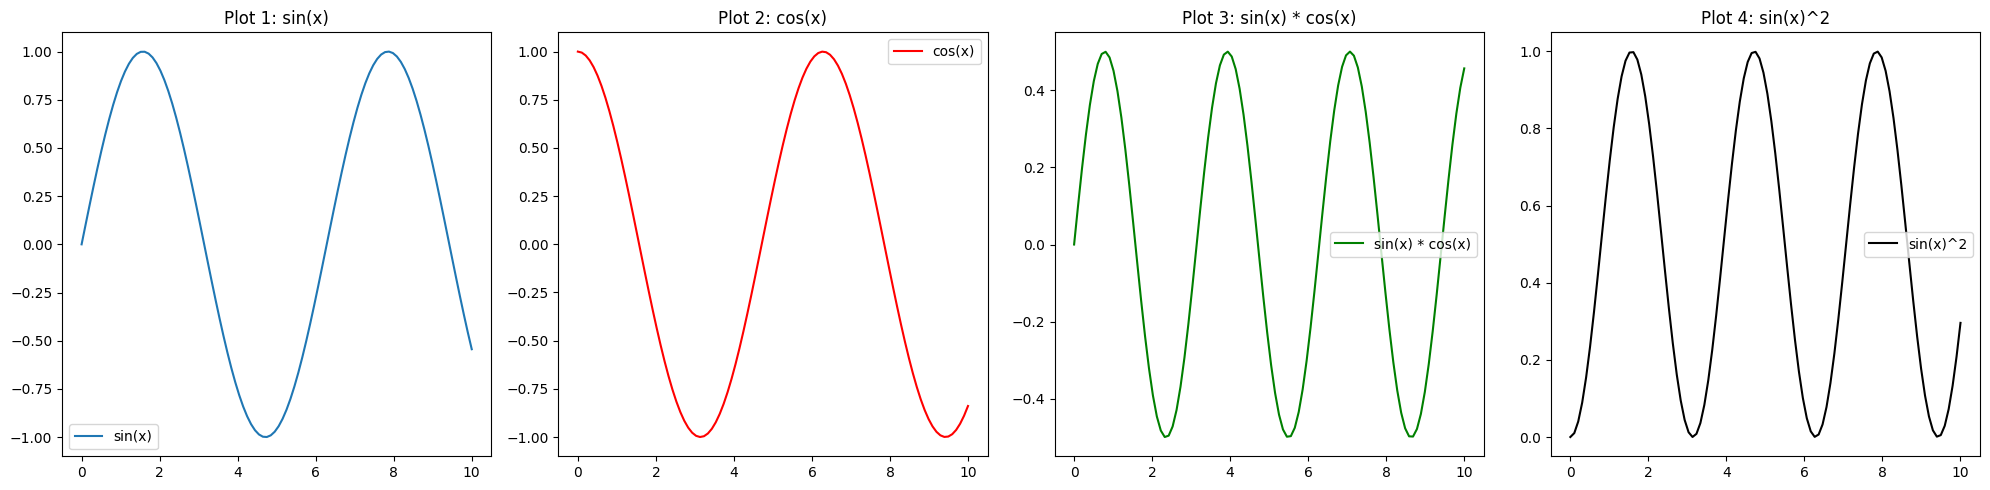

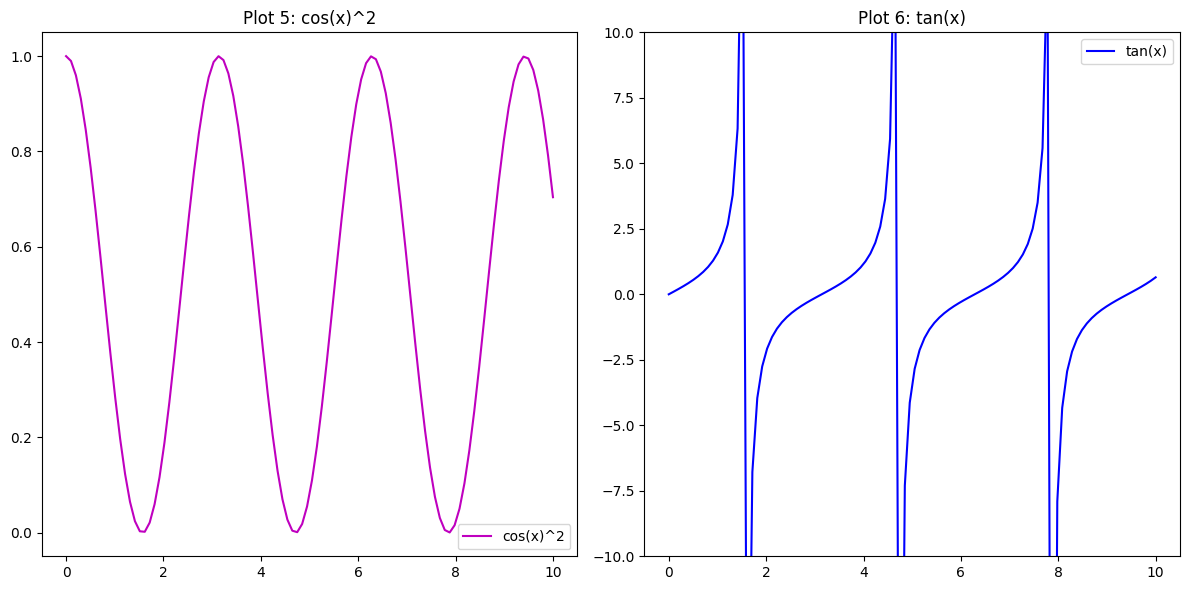

In [27]:
import matplotlib.pyplot as plt
import numpy as np

# Example data generation
x = np.linspace(0, 10, 100)
y1 = np.sin(x)
y2 = np.cos(x)
y3 = np.sin(x) * np.cos(x)
y4 = np.sin(x)**2
y5 = np.cos(x)**2
y6 = np.tan(x)

# Plotting 4 subplots horizontally (1x4 grid)
plt.figure(figsize=(20, 5))  # Adjust figure size for better fit
plt.subplot(1, 4, 1)  # First subplot in a 1x4 grid
plt.plot(x, y1, label='sin(x)')
plt.title('Plot 1: sin(x)')
plt.legend()

plt.subplot(1, 4, 2)  # Second subplot in a 1x4 grid
plt.plot(x, y2, 'r', label='cos(x)')
plt.title('Plot 2: cos(x)')
plt.legend()

plt.subplot(1, 4, 3)  # Third subplot in a 1x4 grid
plt.plot(x, y3, 'g', label='sin(x) * cos(x)')
plt.title('Plot 3: sin(x) * cos(x)')
plt.legend()

plt.subplot(1, 4, 4)  # Fourth subplot in a 1x4 grid
plt.plot(x, y4, 'k', label='sin(x)^2')
plt.title('Plot 4: sin(x)^2')
plt.legend()

plt.tight_layout()  # Adjust layout to not overlap
plt.show()  # Display the plots

# Plotting 2 subplots horizontally (1x2 grid)
plt.figure(figsize=(12, 6))  # Adjust figure size for better fit
plt.subplot(1, 2, 1)  # First subplot in a 1x2 grid
plt.plot(x, y5, 'm', label='cos(x)^2')
plt.title('Plot 5: cos(x)^2')
plt.legend()

plt.subplot(1, 2, 2)  # Second subplot in a 1x2 grid
plt.plot(x, y6, 'b', label='tan(x)')
plt.title('Plot 6: tan(x)')
plt.ylim(-10, 10)  # Limiting y-axis values due to tan(x) function characteristics
plt.legend()

plt.tight_layout()  # Adjust layout to not overlap
plt.show()  # Display the plots
